In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

df       = pd.read_csv('../data/superstore_cleaned.csv')
sim_df   = pd.read_csv('../outputs/pricing_summary.csv')
best_df  = pd.read_csv('../outputs/best_scenario_per_subcategory.csv')
elast_df = pd.read_csv('../outputs/elasticity_by_subcategory.csv')

print("All files loaded")

All files loaded


In [2]:
def assign_action(row):
    scenario = row['Scenario']
    profit   = row['New_Profit']

    if profit < 0:
        return 'High Risk — Persistent Loss-Making'
    elif scenario in ['Price +5%', 'Price +10%']:
        return 'Increase Price'
    elif scenario in ['Price -5%', 'Price -10%', 'Price -20%']:
        return 'Reduce Price / Review Discounting'
    else:
        return 'Hold Current Price'

best_df['Action_Group'] = best_df.apply(assign_action, axis=1)

print("Action Group Distribution")
print(best_df['Action_Group'].value_counts())
print()
print(best_df[['Sub-Category', 'Category', 'Scenario',
                'Profit_Change', 'Action_Group']].to_string(index=False))

Action Group Distribution
Action_Group
Increase Price                        14
High Risk — Persistent Loss-Making     3
Name: count, dtype: int64

Sub-Category        Category   Scenario  Profit_Change                       Action_Group
 Accessories      Technology Price +10%        3954.96                     Increase Price
  Appliances Office Supplies Price +10%        1488.00                     Increase Price
         Art Office Supplies Price +10%         684.27                     Increase Price
     Binders Office Supplies Price +10%        5464.62                     Increase Price
   Bookcases       Furniture Price -20%        1374.58 High Risk — Persistent Loss-Making
      Chairs       Furniture Price +10%        4280.30                     Increase Price
     Copiers      Technology Price +10%        3466.83                     Increase Price
   Envelopes Office Supplies Price +10%        1053.75                     Increase Price
   Fasteners Office Supplies  Price +5%   

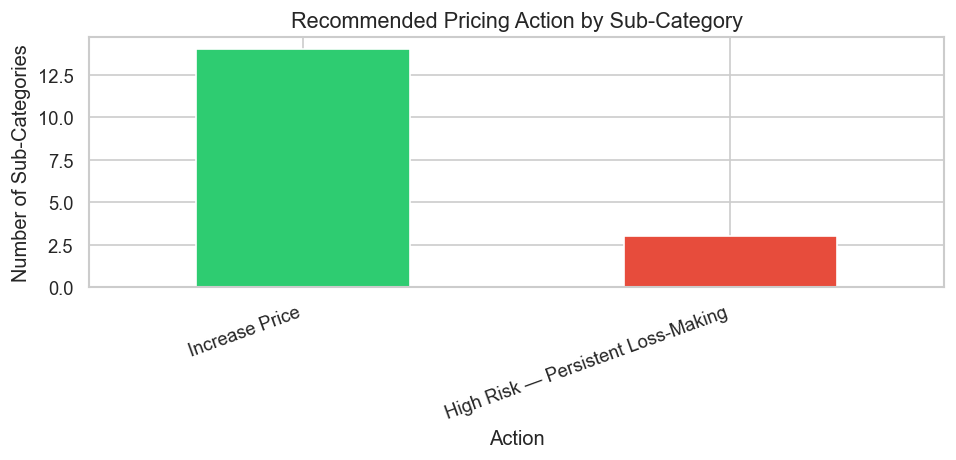

In [3]:
action_counts = best_df['Action_Group'].value_counts()

colors = {
    'Increase Price'                     : '#2ecc71',
    'Hold Current Price'                 : '#3498db',
    'Reduce Price / Review Discounting'  : '#f39c12',
    'High Risk — Persistent Loss-Making' : '#e74c3c'
}

plt.figure(figsize=(8, 4))
action_counts.plot(
    kind='bar',
    color=[colors.get(x, '#95a5a6') for x in action_counts.index]
)
plt.title("Recommended Pricing Action by Sub-Category", fontsize=13)
plt.xlabel("Action")
plt.ylabel("Number of Sub-Categories")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../outputs/17_action_groups.png')
plt.show()

In [5]:
discount_summary = df.groupby('Discount_Band')['Profit_Margin'].mean().round(2)

print("Discount Strategy Analysis")
print(discount_summary)
print()

print("Recommendation:")
for band, margin in discount_summary.items():
    if margin > 0:
        status = f"Safe   → avg margin {margin}%"
    else:
        status = f"Avoid  → avg margin {margin}% (loss-making)"
    print(f"  {str(band):25} {status}")

print()
print("Key Insight:")
print("  Discount bands above 20% show negative average margins,")
print("  indicating unsustainable pricing practices.")

Discount Strategy Analysis
Discount_Band
High (41%+)       -108.83
Low (1-20%)         17.42
Medium (21-40%)    -16.71
No Discount         34.00
Name: Profit_Margin, dtype: float64

Recommendation:
  High (41%+)               Avoid  → avg margin -108.83% (loss-making)
  Low (1-20%)               Safe   → avg margin 17.42%
  Medium (21-40%)           Avoid  → avg margin -16.71% (loss-making)
  No Discount               Safe   → avg margin 34.0%

Key Insight:
  Discount bands above 20% show negative average margins,
  indicating unsustainable pricing practices.


In [6]:
bundle_base = df.groupby('Sub-Category').agg(
    Total_Profit=('Profit', 'sum'),
    Total_Revenue=('Revenue', 'sum'),
    Avg_Quantity=('Quantity', 'mean'),
    Avg_Profit_Margin=('Profit_Margin', 'mean')
).round(2).reset_index()

bundle_base['Bundle_Candidate'] = np.where(
    bundle_base['Total_Profit'] < 0, 'Bundle Instead of Discount',
    np.where(
        (bundle_base['Avg_Profit_Margin'] < 10) &
        (bundle_base['Avg_Quantity'] > 3),
        'Bundle to Increase Order Value',
        'Standard Pricing'
    )
)

print("Bundling Strategy")
print(bundle_base[['Sub-Category', 'Total_Profit',
                    'Avg_Profit_Margin', 'Bundle_Candidate']].to_string(index=False))

Bundling Strategy
Sub-Category  Total_Profit  Avg_Profit_Margin               Bundle_Candidate
 Accessories      41936.64              21.82               Standard Pricing
  Appliances      18138.01             -15.69 Bundle to Increase Order Value
         Art       6524.61              25.16               Standard Pricing
     Binders      30228.00             -19.86 Bundle to Increase Order Value
   Bookcases      -3472.56             -12.66     Bundle Instead of Discount
      Chairs      26567.13               4.40 Bundle to Increase Order Value
     Copiers      55617.82              31.72               Standard Pricing
   Envelopes       6964.18              42.31               Standard Pricing
   Fasteners        949.52              29.92               Standard Pricing
 Furnishings      13052.72              13.69               Standard Pricing
      Labels       5526.38              42.95               Standard Pricing
    Machines       3384.76              -7.20 Bundle to In

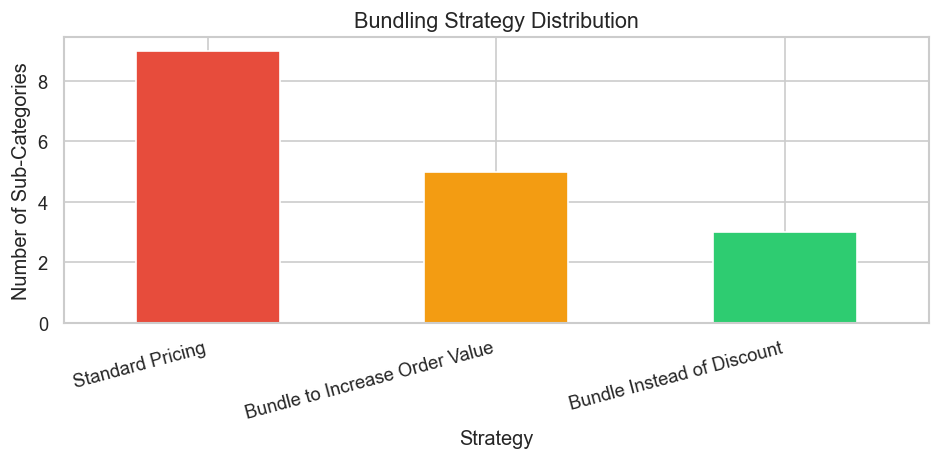

In [7]:
bundle_counts = bundle_base['Bundle_Candidate'].value_counts()

plt.figure(figsize=(8, 4))
bundle_counts.plot(kind='bar', color=['#e74c3c', '#f39c12', '#2ecc71'])
plt.title("Bundling Strategy Distribution", fontsize=13)
plt.xlabel("Strategy")
plt.ylabel("Number of Sub-Categories")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../outputs/18_bundling_strategy.png')
plt.show()

In [8]:
final = best_df[['Sub-Category', 'Category', 'Scenario',
                  'New_Profit', 'Profit_Change', 'Action_Group']].copy()

final = final.merge(
    elast_df[['Sub-Category', 'Proxy_Elasticity', 'Demand_Response']],
    on='Sub-Category', how='left'
)

final = final.merge(
    bundle_base[['Sub-Category', 'Bundle_Candidate']],
    on='Sub-Category', how='left'
)

final = final.sort_values('Profit_Change', ascending=False).reset_index(drop=True)

print("FINAL RECOMMENDATION TABLE")
print(final.to_string(index=False))

FINAL RECOMMENDATION TABLE
Sub-Category        Category   Scenario  New_Profit  Profit_Change                       Action_Group  Proxy_Elasticity          Demand_Response               Bundle_Candidate
     Binders Office Supplies Price +10%    35692.62        5464.62                     Increase Price            -0.036 Inelastic — Price Stable Bundle to Increase Order Value
      Tables       Furniture Price -20%   -13338.21        4387.27 High Risk — Persistent Loss-Making             0.249    Unusual — Investigate     Bundle Instead of Discount
       Paper Office Supplies Price +10%    38284.54        4340.30                     Increase Price            -0.037 Inelastic — Price Stable               Standard Pricing
      Chairs       Furniture Price +10%    30847.43        4280.30                     Increase Price             0.602    Unusual — Investigate Bundle to Increase Order Value
 Accessories      Technology Price +10%    45891.60        3954.96                     Increa

In [9]:
final.to_csv('../outputs/recommendation_table.csv', index=False)
print("Final recommendation table saved")

Final recommendation table saved


In [10]:
print("       FINAL PRICING RECOMMENDATIONS")

print("""
Decision Priority: Profit over Revenue
All recommendations are optimized for profit, not revenue,
as revenue growth without margin leads to value destruction.
""")

print("1. PRICE INCREASE — Safe Opportunities")
increase = best_df[best_df['Action_Group'] == 'Increase Price']
for _, row in increase.iterrows():
    print(f"  • {row['Sub-Category']:20} → {row['Scenario']:12}"
          f" | Profit change: +${row['Profit_Change']:,.0f}")

print()
print("2. HIGH RISK — Persistent Loss-Making")
urgent = best_df[best_df['Action_Group'] == 'High Risk — Persistent Loss-Making']
for _, row in urgent.iterrows():
    print(f"  • {row['Sub-Category']:20} → Reduce discounts immediately"
          f" | Current loss: ${row['New_Profit']:,.0f}")

print()
print("3. REVIEW DISCOUNTING — Price Reduction Cases")
review = best_df[best_df['Action_Group'] == 'Reduce Price / Review Discounting']
for _, row in review.iterrows():
    print(f"  • {row['Sub-Category']:20} → {row['Scenario']:12}"
          f" | Profit change: ${row['Profit_Change']:,.0f}")

print()
print("4. DISCOUNT STRATEGY — Safe Ceiling")
discount_summary = df.groupby('Discount_Band')['Profit_Margin'].mean().round(2)
for band, margin in discount_summary.items():
    if margin > 0:
        status = f"Safe   → avg margin {margin}%"
    else:
        status = f"Avoid  → avg margin {margin}% (loss-making)"
    print(f"  {str(band):25} {status}")
print()
print("Discount cap recommendation: MAX 20% across all categories")
print("Discount bands above 20% show negative average margins.")

print()
print("5. BUNDLING STRATEGY")
bundle_rec = bundle_base[bundle_base['Bundle_Candidate'] != 'Standard Pricing']
for _, row in bundle_rec.iterrows():
    print(f"  • {row['Sub-Category']:20} → {row['Bundle_Candidate']}")

print()
print("Methodology Note")
print("  All recommendations are based on observed demand response")
print("  patterns and directional scenario simulation.")
print("  These are strategic guidelines, not exact price forecasts.")

       FINAL PRICING RECOMMENDATIONS

Decision Priority: Profit over Revenue
All recommendations are optimized for profit, not revenue,
as revenue growth without margin leads to value destruction.

1. PRICE INCREASE — Safe Opportunities
  • Accessories          → Price +10%   | Profit change: +$3,955
  • Appliances           → Price +10%   | Profit change: +$1,488
  • Art                  → Price +10%   | Profit change: +$684
  • Binders              → Price +10%   | Profit change: +$5,465
  • Chairs               → Price +10%   | Profit change: +$4,280
  • Copiers              → Price +10%   | Profit change: +$3,467
  • Envelopes            → Price +10%   | Profit change: +$1,054
  • Fasteners            → Price +5%    | Profit change: +$-5
  • Furnishings          → Price +10%   | Profit change: +$2,682
  • Labels               → Price +10%   | Profit change: +$288
  • Machines             → Price +10%   | Profit change: +$614
  • Paper                → Price +10%   | Profit change: 

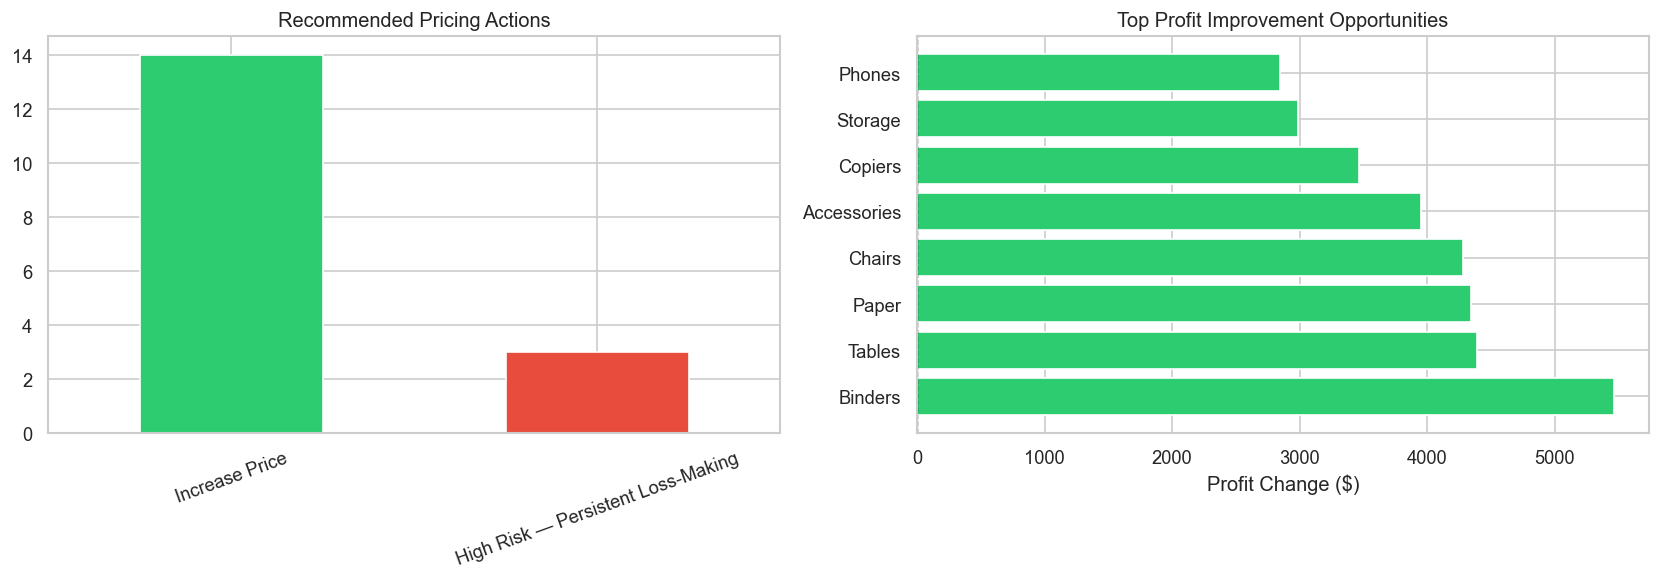

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — Action group distribution
action_counts = best_df['Action_Group'].value_counts()
colors_list = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']
action_counts.plot(kind='bar', ax=axes[0], color=colors_list)
axes[0].set_title("Recommended Pricing Actions", fontsize=12)
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=20)

# Right — Top profit improvement sub-categories
top_improve = best_df.nlargest(8, 'Profit_Change')
axes[1].barh(top_improve['Sub-Category'], top_improve['Profit_Change'],
             color='#2ecc71')
axes[1].set_title("Top Profit Improvement Opportunities", fontsize=12)
axes[1].set_xlabel("Profit Change ($)")
axes[1].axvline(0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('../outputs/19_final_summary.png')
plt.show()

Final Recommendations — Conclusions

Decision Priority — Profit over Revenue
All recommendations are optimized for profit, not revenue, as revenue growth without margin leads to value destruction. A pricing strategy that increases sales volume but reduces profit is not a successful strategy — it is a hidden loss.

1. Price Increase is the Dominant Recommendation
13 out of 17 sub-categories show Price +10% as most profitable scenario. The business is currently underpricing across most product lines. Modest price increases of 5–10% can significantly improve profit without major demand risk in stable sub-categories.

2. Three Sub-Categories Need Immediate Attention
Tables, Bookcases, and Supplies are persistently loss-making. Even the best pricing scenario cannot fully recover their profit.
Recommended actions:
- Eliminate or strictly cap discounts on these products
- Bundle with high-margin products instead of discounting
- Review base cost and supplier pricing structure

3. Discount Cap — Maximum 20%
Data clearly shows profit turns negative beyond 20% discount. Discount bands above 20% show negative average margins, indicating unsustainable pricing practices.
Recommendation: enforce a hard discount ceiling of 20% across all categories.

4. Bundling over Discounting
For loss-making and low-margin sub-categories, bundling is a more effective strategy than price cuts. It increases average order value without sacrificing margin.

5. Category-Specific Strategy is Essential
- Technology → premium pricing, minimal discounting
- Office Supplies → stable pricing, volume focus
- Furniture → urgent restructuring needed

Final Statement
Based on observed demand response patterns and scenario simulation, this analysis recommends a shift from discount-heavy pricing to value-based pricing with category-specific strategies that prioritize profit over volume. All recommendations are directional and should be validated with controlled pricing experiments before full implementation.